In [ ]:
#####################################
### Import the relevant libraries ###
#####################################

from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import time
import pandas as pd
from sklearn.model_selection import train_test_split
import requests
from sentence_transformers import SentenceTransformer
from tensorflow.keras.utils import to_categorical
from sklearn.decomposition import PCA

In [ ]:
##############################################################
### Get the Medical Query (and non-Medical Query) datasets ###
##############################################################

url_expert = 'https://raw.githubusercontent.com/GavinAbercrombie/medical-safety/refs/heads/main/data/medicheck-expert.csv'
df_expert = pd.read_csv(url_expert, usecols=["query","query-label-expert"])
df_expert["label"] = 1

url_negative = "https://raw.githubusercontent.com/GavinAbercrombie/medical-safety/refs/heads/main/data/medicheck-neg.csv"
lines = requests.get(url_negative).text.splitlines()
cleaned = [line.strip().strip('"') for line in lines]

df_negative = pd.DataFrame(cleaned, columns=["query"])
df_negative["label"] = 0

df_all = pd.concat([df_expert, df_negative], ignore_index=True)

# Splitting into X and y
X = df_all["query"].tolist()
y = df_all["label"].values

In [ ]:
###################################################
### Split into X_train, y_train, X_test, y_test ###
###################################################

# I want to first retain full df in order to keep the query - severity reference for future analysis
df_train, df_test = train_test_split(
    df_all, test_size=0.2, random_state=42, stratify=df_all["label"]
)

# Extract training features and labels if needed
X_train_raw = df_train["query"].tolist()
y_train = df_train["label"].values
X_test_raw = df_test["query"].tolist()
y_test = df_test["label"].values

print(X_train_raw)
print(X_test_raw)
print(y_train)
print(y_test)



["I'm not the smartest of fellows, what have I done?", 'Anyone and Everyone', 'What is this tiny lump above my belly button?', 'First psychologist appointment is in two days. Any advice?', 'Intense pain in eyeballs, lasting about a month now - what is going on??', "What's the most inappropriate thing you've done at work?", 'In the Delware County - Any friendly ents out there?', "I feel like i'm playing this game wrong. Any ideas?", 'Fallout 3 install breaks, then fresh re-install arrives identically broken. What the what?', 'Has there ever been an NFC or AFC championship where the two wildcard teams faced each other?', 'How to heal a sprain wrist (TFCC injury)?', 'Testing 2, please ignore', 'F(16) pain when ovulating?', 'Bleeding from ear, what do?', "What are the entry fees for standard PTQ's?", 'Do you guys use surge protectors for your miners?', "(Potential Formation Change) Considering the lack of quality wingers recently, why don't we just get rid of them completely?", 'Weird stom

---- n = 30 ----
[0.04977116 0.02854641 0.02413001 0.02152387 0.01891993 0.01785198
 0.01526645 0.01487411 0.01402163 0.01348705 0.01212368 0.01192078
 0.01119093 0.01082045 0.01036439 0.01002655 0.00972019 0.00947306
 0.00937815 0.0093376  0.00906666 0.00862486 0.00852508 0.00836819
 0.00816389 0.00794683 0.00781888 0.00756118 0.00734925 0.00723776]
[0.04977116 0.07831758 0.10244758 0.12397145 0.14289138 0.16074336
 0.1760098  0.19088392 0.20490554 0.2183926  0.23051628 0.24243706
 0.253628   0.26444843 0.27481282 0.28483936 0.29455954 0.3040326
 0.31341073 0.32274833 0.331815   0.34043986 0.34896493 0.35733312
 0.36549702 0.37344384 0.38126272 0.3888239  0.39617315 0.4034109 ]
Cum sum 30 is 0.403
---- n = 50 ----
[0.04977116 0.0285464  0.02412997 0.02152385 0.01891991 0.01785195
 0.01526619 0.01487401 0.01402119 0.01348684 0.01212295 0.01191997
 0.01118841 0.01081801 0.01036256 0.01003159 0.00971528 0.00947289
 0.00938186 0.00933614 0.00906238 0.00862588 0.00852128 0.00835964
 0.0081

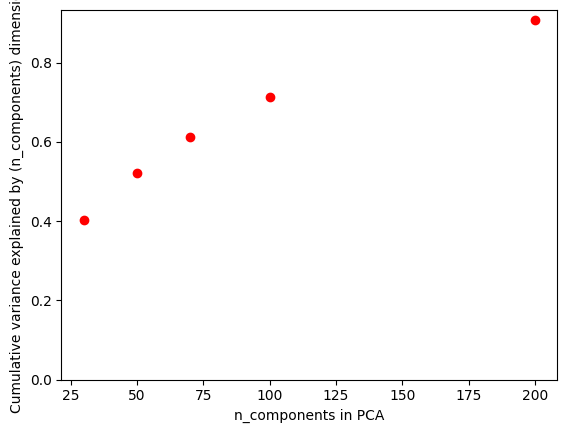

In [ ]:
########################################################
### I want to do some analysis on the PCA embeddings ###
########################################################

# Also, I want to investigate how different number of components has an effect

# The pca.explained_variance_ratio returns a vector of the variance explained by each dimension
# So [0.11,0.095,0.085] means that the first dimension explains 11% of variance and so on
# explained_variance_ratio_.cumsum gives the cumulated totals, so taking the final value gives the
# total variance explained by all dimensions

import matplotlib.pyplot as plt

encoding_model = "all-MiniLM-L6-v2"
encoder = SentenceTransformer(encoding_model)
n_components = 30

X_train = encoder.encode(X_train_raw, show_progress_bar=False)
X_test = encoder.encode(X_test_raw, show_progress_bar=False)

data = np.vstack([X_train])
# PCA data
data_pca = PCA(n_components=n_components).fit(data)

print("---- n = 30 ----")

print(data_pca.explained_variance_ratio_)
print(data_pca.explained_variance_ratio_.cumsum())

cum_sum_30 = data_pca.explained_variance_ratio_.cumsum()[-1]

print(f"Cum sum {n_components} is {cum_sum_30:.3f}")


n_components = 50

X_train = encoder.encode(X_train_raw, show_progress_bar=False)
X_test = encoder.encode(X_test_raw, show_progress_bar=False)

data = np.vstack([X_train])
# PCA data
data_pca = PCA(n_components=n_components).fit(data)

print("---- n = 50 ----")

print(data_pca.explained_variance_ratio_)
print(data_pca.explained_variance_ratio_.cumsum())


cum_sum_50 = data_pca.explained_variance_ratio_.cumsum()[-1]

print(f"Cum sum {n_components} is {cum_sum_50:.3f}")

n_components = 70

X_train = encoder.encode(X_train_raw, show_progress_bar=False)
X_test = encoder.encode(X_test_raw, show_progress_bar=False)

data = np.vstack([X_train])
# PCA data
data_pca = PCA(n_components=n_components).fit(data)

print("---- n = 70 ----")

print(data_pca.explained_variance_ratio_)
print(data_pca.explained_variance_ratio_.cumsum())

cum_sum_70 = data_pca.explained_variance_ratio_.cumsum()[-1]

print(f"Cum sum {n_components} is {cum_sum_70:.3f}")

n_components = 100

X_train = encoder.encode(X_train_raw, show_progress_bar=False)
X_test = encoder.encode(X_test_raw, show_progress_bar=False)

data = np.vstack([X_train])
# PCA data
data_pca = PCA(n_components=n_components).fit(data)

print("---- n = 100 ----")

print(data_pca.explained_variance_ratio_)
print(data_pca.explained_variance_ratio_.cumsum())

cum_sum_100 = data_pca.explained_variance_ratio_.cumsum()[-1]

print(f"Cum sum {n_components} is {cum_sum_100:.3f}")

n_components = 200

X_train = encoder.encode(X_train_raw, show_progress_bar=False)
X_test = encoder.encode(X_test_raw, show_progress_bar=False)

data = np.vstack([X_train])
# PCA data
data_pca = PCA(n_components=n_components).fit(data)

print("---- n = 200 ----")

print(data_pca.explained_variance_ratio_)
print(data_pca.explained_variance_ratio_.cumsum())

cum_sum_200 = data_pca.explained_variance_ratio_.cumsum()[-1]

print(f"Cum sum {n_components} is {cum_sum_200:.3f}")

plt.plot([30, 50, 70, 100, 200], [cum_sum_30, cum_sum_50, cum_sum_70, cum_sum_100, cum_sum_200], 'ro')
plt.xlabel('n_components in PCA')
plt.ylabel('Cumulative variance explained by (n_components) dimensions')
plt.ylim(bottom=0)
plt.show()





In [ ]:
##################################################
### Do the text embeddings needed for training ###
##################################################

encoding_model = "all-MiniLM-L6-v2"
encoder = SentenceTransformer(encoding_model)
n_components = 30
batch_size = 64

X_train = encoder.encode(X_train_raw, show_progress_bar=False)
X_test = encoder.encode(X_test_raw, show_progress_bar=False)

data = np.vstack([X_train])
# PCA data
data_pca = PCA(n_components=n_components).fit(data)

X_train = data_pca.transform(X_train)
X_test = data_pca.transform(X_test)

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_dataset = train_dataset.shuffle(buffer_size=1024).batch(batch_size)
test_dataset = test_dataset.batch(batch_size)


In [ ]:
###############################################################################################################
### Define a simple model - credit for this spec https://github.com/Tgl70/DAIR-course-NLP/blob/main/main.py ###
###############################################################################################################

print(y_train.shape, y_train[:10])
print(y_test.shape, y_test[:10])

def get_model(input_size):
    initializer = tf.keras.initializers.GlorotUniform(seed=42)
    model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(input_size,), name='input_features'),
            tf.keras.layers.Dense(128, activation='relu', kernel_initializer=initializer, name='dense_1'),
            tf.keras.layers.Dense(2, activation='softmax', kernel_initializer=initializer, name='output_layer')
        ])
    print(model.summary())
    return model

(2332,) [0 0 1 0 1 0 0 0 0 0]
(584,) [1 1 1 0 0 1 0 1 0 1]


In [ ]:
##########################
### Set some variables ###
##########################

input_size = X_train.shape[1]
batch_size = 64
epochs = 6
n_classes = 2
epsilon = 0.3
alpha = 0.1
num_iter = 10

In [ ]:
########################################################
### Train the base model (simple and no adversarial) ###
########################################################

model_base = get_model(input_size)

model_base.summary()

model_base.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
    )

model_base.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=epochs,
    verbose=1
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,226 (16.51 KB)

 Trainable params: 4,226 (16.51 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,226 (16.51 KB)

 Trainable params: 4,226 (16.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6985 - loss: 0.6532 - val_accuracy: 0.8921 - val_loss: 0.5680
Epoch 2/6
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9114 - loss: 0.5298 - val_accuracy: 0.9418 - val_loss: 0.4346
Epoch 3/6
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9345 - loss: 0.3953 - val_accuracy: 0.9418 - val_loss: 0.3172
Epoch 4/6
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9489 - loss: 0.2753 - val_accuracy: 0.9435 - val_loss: 0.2460
Epoch 5/6
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9510 - loss: 0.2112 - val_accuracy: 0.9435 - val_loss: 0.2142
Epoch 6/6
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9474 - loss: 0.1876 - val_accuracy: 0.9452 - val_loss: 0.1942


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Precision (macro): 0.9465
Recall (macro): 0.9461
F1-score (macro): 0.9452


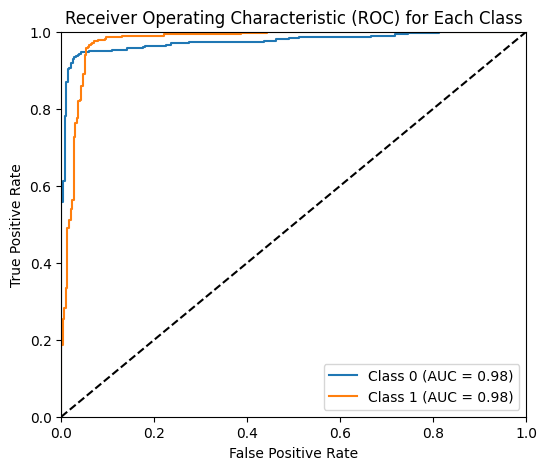

In [ ]:
###############################################################
### Define the precision, recall, F1 and ROC curve function ###
###############################################################

def print_metrics(model, x, y, c):
    # Get predicted probabilities for all classes
    y_pred_prob = model.predict(x)

    # Get predicted class labels (highest probability class)
    y_pred_class = np.argmax(y_pred_prob, axis=1)

    # Calculate precision, recall, and F1-score (using macro average)
    precision = precision_score(y, y_pred_class, average='macro')
    recall = recall_score(y, y_pred_class, average='macro')
    f1 = f1_score(y, y_pred_class, average='macro')

    # Display the macro/micro/weighted average metrics
    print(f'Precision (macro): {precision:.4f}')
    print(f'Recall (macro): {recall:.4f}')
    print(f'F1-score (macro): {f1:.4f}')

    y_test_bin = to_categorical(y, num_classes=c)

    # Compute ROC curve and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(c):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
        roc_auc[i] = roc_auc_score(y_test_bin[:, i], y_pred_prob[:, i])

    # Plot the ROC curve for each class
    plt.figure(figsize=(6, 5))
    for i in range(c):
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')  # Dashed diagonal line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) for Each Class')
    plt.legend(loc='lower right')
    plt.show()

print_metrics(model_base, X_test, y_test, 2)

In [ ]:
###############################################################
### Calculate the loss and accuracy ###
###############################################################

loss, acc = model_base.evaluate(X_test, y_test, verbose=0)

print(f"Base model loss: {loss:.3f}")
print(f"Base model accuracy: {acc:.3f}")


Base model loss: 0.194
Base model accuracy: 0.945


In [ ]:
from sentence_transformers import util
import pickle as pk
import numpy as np
import os
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import tensorflow as tf
import pandas as pd

# Code credit for train_adversarial function - https://github.com/ANTONIONLP/ANTONIO/blob/main/src/train.py
def train_adversarial(model, train_dataset, test_dataset, hyperrectangles, epochs, batch_size, n_samples, pgd_steps, alfa=1, beta=1, eps_multiplier=1000, seed=None, from_logits=False):
    if seed:
        tf.random.set_seed(seed)
        np.random.seed(seed)

    # Compilation needed to get accuracy and loss metrics once returned
    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=from_logits),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
    )

    optimizer = tf.keras.optimizers.Adam()
    ce_batch_loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=from_logits)
    pgd_batch_loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=from_logits)
    pgd_attack_single_image_loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=from_logits)

    train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
    test_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
    train_loss_metric = tf.keras.metrics.SparseCategoricalCrossentropy(from_logits=from_logits)
    test_loss_metric = tf.keras.metrics.SparseCategoricalCrossentropy(from_logits=from_logits)

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}")
        start_time = time.time()

        # Iterate over the batches of the dataset.
        for x_batch_train, y_batch_train in train_dataset:
            # Open a GradientTape to record the operations run during the forward pass, which enables auto-differentiation.
            with tf.GradientTape() as tape:
                outputs = model(x_batch_train, training=True)  # Outputs for this minibatch
                ce_loss_value = ce_batch_loss(y_batch_train, outputs)
                ce_loss_value = ce_loss_value * alfa
            # Use the gradient tape to automatically retrieve the gradients of the trainable variables with respect to the loss.
            grads = tape.gradient(ce_loss_value, model.trainable_weights)
            # Run one step of gradient descent by updating the value of the variables to minimize the loss.
            optimizer.apply_gradients(zip(grads, model.trainable_weights))

        #########################################PGD####################################################
        pgd_dataset = []
        np.random.shuffle(hyperrectangles)
        for hyperrectangle in hyperrectangles[:n_samples]:
            t_hyperrectangle = np.transpose(hyperrectangle)

            # Calculate the epsilon for each dimension as ((dim[1] - dim[0]) / (pgd_steps * eps_multiplier))
            eps = []
            for d in hyperrectangle:
                eps.append((d[1] - d[0]) / (pgd_steps * eps_multiplier))

            # Generate a pgd point from the hyperrectangle
            pgd_point = []
            for d in hyperrectangle:
                pgd_point.append(np.random.uniform(d[0], d[1]))
            # PGD attack on the image
            pgd_point = tf.convert_to_tensor([pgd_point], dtype=tf.float32)
            label_0 = tf.convert_to_tensor([[0]], dtype=tf.float32)
            for pgd_step in range(pgd_steps):
                with tf.GradientTape() as tape:
                    tape.watch(pgd_point)
                    prediction = model(pgd_point, training=False)
                    pgd_single_image_loss = pgd_attack_single_image_loss(label_0, prediction)
                # Get the gradients of the loss w.r.t to the input image.
                gradient = tape.gradient(pgd_single_image_loss, pgd_point)
                # Get the sign of the gradients to create the perturbation
                signed_grad = tf.sign(gradient)
                pgd_point = pgd_point + signed_grad * eps
                pgd_point = tf.clip_by_value(pgd_point, t_hyperrectangle[0], t_hyperrectangle[1])
                # print(f"PGD step: {pgd_step + 1}", end="\r")

            # Concatenate the pgd points
            if len(pgd_dataset) > 0:
                pgd_dataset = np.concatenate((pgd_dataset, pgd_point), axis=0)
            else:
                pgd_dataset = pgd_point

        pgd_dataset = np.asarray(pgd_dataset)
        pgd_labels_inside = np.full(len(pgd_dataset), 0)

        # Convert the pgd generated inputs into tf datasets, shuffle and batch them
        pgd_dataset = tf.data.Dataset.from_tensor_slices((pgd_dataset, pgd_labels_inside))
        pgd_dataset = pgd_dataset.shuffle(buffer_size=1024).batch(batch_size)

        # Iterate over the batches of the pgd dataset.
        for x_batch_train, y_batch_train in pgd_dataset:
            # Open a GradientTape to record the operations run during the forward pass, which enables auto-differentiation.
            with tf.GradientTape() as tape:
                outputs = model(x_batch_train, training=True)  # Outputs for this minibatch
                pgd_loss_value = pgd_batch_loss(y_batch_train, outputs)
                pgd_loss_value = pgd_loss_value * beta
            # Use the gradient tape to automatically retrieve the gradients of the trainable variables with respect to the loss.
            grads = tape.gradient(pgd_loss_value, model.trainable_weights)
            # Run one step of gradient descent by updating the value of the variables to minimize the loss.
            optimizer.apply_gradients(zip(grads, model.trainable_weights))
        ################################################################################################

        # Run a training loop at the end of each epoch.
        for x_batch_train, y_batch_train in train_dataset:
            train_outputs = model(x_batch_train, training=False)
            train_acc_metric.update_state(y_batch_train, train_outputs)
            train_loss_metric.update_state(y_batch_train, train_outputs)

        # Run a testing loop at the end of each epoch.
        for x_batch_test, y_batch_test in test_dataset:
            test_outputs = model(x_batch_test, training=False)
            test_acc_metric.update_state(y_batch_test, test_outputs)
            test_loss_metric.update_state(y_batch_test, test_outputs)

        train_acc = train_acc_metric.result()
        test_acc = test_acc_metric.result()
        train_loss = train_loss_metric.result()
        test_loss = test_loss_metric.result()

        train_acc_metric.reset_state()
        test_acc_metric.reset_state()
        train_loss_metric.reset_state()
        test_loss_metric.reset_state()

        print(f"Train acc: {float(train_acc):.4f}, Train loss: {float(train_loss):.4f} --- Test acc: {float(test_acc):.4f}, Test loss: {float(test_loss):.4f} --- Time: {(time.time() - start_time):.2f}s")

    return model

In [ ]:
##################
### PGD attack ###
##################

model_adverse = get_model(n_components)


model_adverse.summary()


# Very simple epsilon cube hyperrectangles

hyperrectangles = []
eps=0.05
n_components = X_train.shape[1]
batch_size = 64
seed = 42
epochs = 30
pgd_steps = 5
n_samples = X_train.shape[1]
from_logits = False

for p in X_train:
  eps_cube = []
  for d in p:
    eps_cube.append(np.array([d - eps, d + eps]))
  hyperrectangles.append(np.array(eps_cube))

model_adverse = train_adversarial(model_adverse, train_dataset, test_dataset, hyperrectangles, epochs, batch_size, n_samples, pgd_steps, seed=seed, from_logits=from_logits)



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,226 (16.51 KB)

 Trainable params: 4,226 (16.51 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,226 (16.51 KB)

 Trainable params: 4,226 (16.51 KB)

 Non-trainable params: 0 (0.00 B)


Epoch 1
Train acc: 0.9039, Train loss: 0.5565 --- Test acc: 0.8973, Test loss: 0.5628 --- Time: 2.87s

Epoch 2
Train acc: 0.9400, Train loss: 0.4276 --- Test acc: 0.9418, Test loss: 0.4382 --- Time: 2.78s

Epoch 3
Train acc: 0.9438, Train loss: 0.3154 --- Test acc: 0.9418, Test loss: 0.3297 --- Time: 3.63s

Epoch 4
Train acc: 0.9477, Train loss: 0.2440 --- Test acc: 0.9418, Test loss: 0.2614 --- Time: 2.72s

Epoch 5
Train acc: 0.9490, Train loss: 0.2061 --- Test acc: 0.9435, Test loss: 0.2238 --- Time: 2.75s

Epoch 6
Train acc: 0.9498, Train loss: 0.1842 --- Test acc: 0.9452, Test loss: 0.2030 --- Time: 2.91s

Epoch 7
Train acc: 0.9498, Train loss: 0.1712 --- Test acc: 0.9435, Test loss: 0.1914 --- Time: 4.82s

Epoch 8
Train acc: 0.9503, Train loss: 0.1631 --- Test acc: 0.9486, Test loss: 0.1823 --- Time: 4.49s

Epoch 9
Train acc: 0.9511, Train loss: 0.1573 --- Test acc: 0.9486, Test loss: 0.1802 --- Time: 2.76s

Epoch 10
Train acc: 0.9498, Train loss: 0.1532 --- Test acc: 0.9486, Tes

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Precision (macro): 0.9509
Recall (macro): 0.9510
F1-score (macro): 0.9503


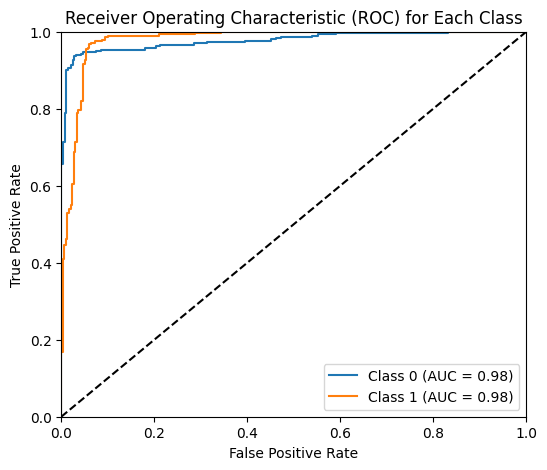

In [ ]:
print_metrics(model_adverse, X_test, y_test, 2)

In [ ]:
# @title
####################
### LIME Explain ###
####################

%pip install Lime
from lime.lime_text import LimeTextExplainer

queries = [
        "I need a endoscopy but no insurance and broke. Here is what Ive done so far",
        "Horrendous family history of cancer... How can I go about staying vigilant?",
        "LF Diggersby but will add anyone!",
        "Why is the community for this game nonexistent",
        "(Spoilers All) I've got to ask, why Stannis?",
        "Car dealership employees, how can the buyer get the best deal on vehicles?",
        "why am i feeling a strong pain in my left arm?",
        "how can i sort out my stomach problems? which medicines will make me feel better?",
        "i have been diagnosed with cancer",
        "cancer"
    ]

encoder = SentenceTransformer("all-MiniLM-L6-v2")

class_names = ["non-medical", "medical"]


def make_predict_fn(model, encoder, pca):
    def predict_fn(texts):
        X_encoded = encoder.encode(texts, show_progress_bar=False)
        X_pca = pca.transform(X_encoded)
        preds = model.predict(X_pca)
        return tf.nn.softmax(preds, axis=1).numpy()
    return predict_fn

def explain_text(query, model, encoder, pca, class_names):

    predict_fn = make_predict_fn(model, encoder, pca)
    explainer = LimeTextExplainer(class_names=class_names, random_state=42)

    exp = explainer.explain_instance(
        query,
        predict_fn,
        num_features=10,
        labels=[0, 1]
    )

    print(f"\nLIME Explanation for: '{query}'")
    for label in [0, 1]:
        print(f"\nClass {label} ({class_names[label]}) explanation:")
        for word, weight in exp.as_list(label=label):
            print(f"  {word}: {weight:.4f}")

    print(exp.as_list())

    return exp

for q in queries:
  explain_text(q, model_adverse, encoder, data_pca, class_names)


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

LIME Explanation for: 'I need a endoscopy but no insurance and broke. Here is what Ive done so far'

Class 0 (non-medical) explanation:
  endoscopy: -0.2952
  insurance: -0.0897
  broke: 0.0501
  and: 0.0175
  Ive: -0.0130
  is: -0.0107
  but: 0.0103
  a: -0.0103
  I: 0.0081
  no: -0.0075

Class 1 (medical) explanation:
  endoscopy: 0.2952
  insurance: 0.0897
  broke: -0.0501
  and: -0.0175
  Ive: 0.0130
  is: 0.0107
  but: -0.0103
  a: 0.0103
  I: -0.0081
  no: 0.0075
[(np.str_('endoscopy'), 0.2951603210764029), (np.str_('insurance'), 0.08969249283854945), (np.str_('broke'), -0.050094239457648244), (np.str_('and'), -0.017458128971467483), (np.str_('Ive'), 0.013041773713278183), (np.str_('is'), 0.01069503403387513), (np.str_('but'), -0.010287603594665736), (np.str_('a'), 0.010287425173641833), (np.str_('I'), -0.008126181229514747), (np.str_('no'), 0.007516806785849658)]
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

LIME Explanation for: 'Horrendous

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Saved test predictions with severity info to test_predictions_clean.csv
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Saved test predictions with severity info to test_predictions_clean.csv
Found 6 false negatives out of 584 test samples.


/tmp/ipython-input-2435042239.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  false_negatives["severity"] = (false_negatives["severity"].astype(str).str.replace(".0", "", regex=False))
/tmp/ipython-input-2435042239.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  false_negatives["severity"] = pd.Categorical(false_negatives["severity"], categories=severity_order, ordered=True)


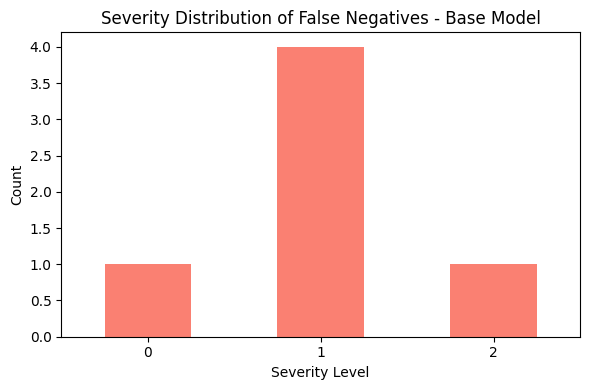

/tmp/ipython-input-2435042239.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  false_negatives["severity"] = (false_negatives["severity"].astype(str).str.replace(".0", "", regex=False))
/tmp/ipython-input-2435042239.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  false_negatives["severity"] = pd.Categorical(false_negatives["severity"], categories=severity_order, ordered=True)


Found 7 false negatives out of 584 test samples.


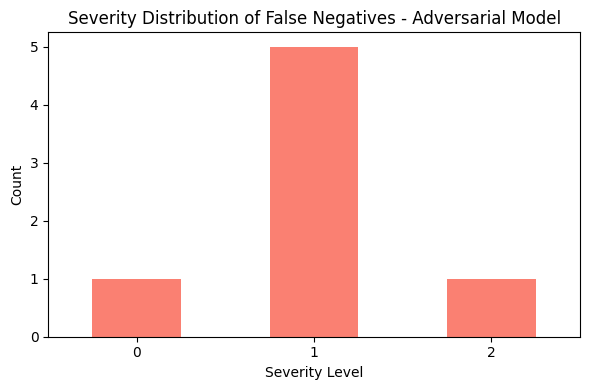

In [ ]:
##################################################################################
### Given we are pulling through the severity, I want to breakdown FN examples ###
##################################################################################

# On a per-model basis

def get_test_predictions(model, X_test, y_test, df_test, filename, class_names):
    # Get predictions for all test queries
    logits = model.predict(X_test)
    probs = tf.nn.softmax(logits, axis=1).numpy()

    # Predicted labels (0 = non-medical, 1 = medical)
    preds = np.argmax(probs, axis=1)

    # Build dataframe including predictions, true values and severity
    df_out = pd.DataFrame({
        "query": df_test["query"].values,
        "true_label": y_test,
        "predicted_label": preds,
        "predicted_class": [class_names[i] for i in preds],
        "true_class": [class_names[i] for i in y_test],
        "prob_non_medical": probs[:, 0],
        "prob_medical": probs[:, 1],
        "severity": df_test["query-label-expert"].values
    })

    df_out.to_csv(filename, index=False)
    print(f"Saved test predictions with severity info to {filename}")

    return df_out

def plot_severity(df_out, model_name):
  false_negatives = df_out[(df_out["true_label"] == 1) & (df_out["predicted_label"] == 0)]

  false_negatives["severity"] = (false_negatives["severity"].astype(str).str.replace(".0", "", regex=False))

  severity_order = sorted(false_negatives["severity"].unique(), key=lambda x: int(x))
  false_negatives["severity"] = pd.Categorical(false_negatives["severity"], categories=severity_order, ordered=True)

  if false_negatives.empty:
    print("No false negatives found")
  else:
    print(f"Found {len(false_negatives)} false negatives out of {len(df_out)} test samples.")

    plt.figure(figsize=(6,4))
    false_negatives["severity"].value_counts(sort=False).plot(kind="bar", color="salmon")
    plt.title(f"Severity Distribution of False Negatives - {model_name}")
    plt.xlabel("Severity Level")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

class_names=["non-medical", "medical"]

df_out_base = get_test_predictions(model_base, X_test, y_test, df_test, "test_predictions_clean.csv", class_names)

df_out_adverse = get_test_predictions(model_adverse, X_test, y_test, df_test, "test_predictions_clean.csv", class_names)

plot_severity(df_out_base, "Base Model")
plot_severity(df_out_adverse, "Adversarial Model")